# Trust region methods

In this section, we'll look at trust region methods.
We have some of the numerical tools that we need already.
In particular, trust region methods for unconstrained optimization build a model of the objective function about a point at each iteration.
Progress towards the minimizer is ensured enforcing sufficient agreement between the model and the true objective.

The basic trust region algorithm we will use is:

1. Set $k = 1$, set an initial trust region radius $\Delta$, set an initial guess $x$
2. If $||\nabla f(x)|| \le \epsilon$ quit
3. Build or update a model function $m_{k}(p) \approx f(x + p)$ for $||p|| \le \Delta$
4. Approximately solve $\min_{p} m_{k}(p)$ such that $||p|| \le \Delta$ to obtain $s$
5. If the design point $x + s$ does not produce a sufficient decrease in $f$, shrink the trust region radius $\Delta$
6. Otherwise accept the step and set $x \leftarrow x + s$, set $k = k+1$ and goto step 2

- Typically the model $m_{k}(p)$ is constructed using a quadratic model $m_{k}(p) = f(x) + \nabla f(x)^{T}p + \frac{1}{2} p^{T}B_{k}p$
- $B_{k}$ is a quasi-Newton Hessian approximation
- Trust region methods allow indefinite or semi-definite Hessian approximations, line search methods do not

## Interactive Trust Region for the Rosenbrock Function

To help visualize the operation of trust region methods, the following applet can be used to investigate the influence of the trust region radius and the construction of the model function. The Rosenbrock function is considered again with the parameters $a = 1$ and $b = 2$.

\begin{equation*}
f(x_1, x_2) = (a-x_1)^2 + b(x_2-x_1^2)^2
\end{equation*}

To interact with the applet, you can drag the blue point on the left, which specifies the current point for building the model function for the trust region method. You can also adjust the trust region radius $\Delta$ using the input box. Here, the model function uses the exact Hessian instead of an approximation. 

In [1]:
from IPython.display import HTML

html_code = """
<script src="https://www.geogebra.org/apps/deployggb.js"></script>
<script>
var params = {"material_id": "jhgmapj8", "showFullScreenButton": true};
var applet = new GGBApplet(params, true);
window.addEventListener("load", function() {
    applet.inject('ggb-element');
});
</script>
<div id="ggb-element"></div>
"""

HTML(html_code)

## Basic trust region algorithm

We need to fill in a few details for the trust region algorithm to work:

1. Set $k = 1$, set an initial trust region radius $\Delta$, set an initial guess and choose $\eta \in [0, 1/4)$ and $\Delta_{\max}$
2. Update the model $m_{k}(p)$
3. Compute an exact or approximate solution to:
\begin{equation*}
s = \text{argmin}_{p} m_{k}(p), \qquad \text{such that}\; ||p||_{2} \le \Delta
\end{equation*}
4. Compute $f(x + s)$, and compute the ratio: 
\begin{equation*}
\rho = \frac{f(x) - f(x + s)}{f(x) - m_{k}(s)}
\end{equation*}
5. If $\rho \ge \eta$, define $x \leftarrow x + s$, otherwise $x$ remains the same
6. Set the new trust region radius:
    1. If $\rho < 0.25$, set $\Delta \leftarrow 0.25\Delta$
    2. Else if $\rho > 0.75$ and $||p^{*}||_{2} == \Delta$ and set $\Delta \leftarrow min(2\Delta, \Delta_{\max})$
    3. Else $\Delta$ remains unchanged
7. Set $k \leftarrow k + 1$, Goto step 2 

## The Cauchy point

We need to find the solution of the constrained minimization problem:

\begin{equation*}
\min_{p} g^{T}p + \frac{1}{2}p^{T}Bp, \qquad \text{such that}\; ||p||_{2} \le \Delta
\end{equation*}

We'll drop the index $k$ and set $g = \nabla f$ to simplify things.
It turns out, we don't need an exact solution. Instead we can use various algorithms that approximate the exact solution to some extent.
This will provide enough progress for convergence of the trust region method, as long as we make as much progress as what's called the Cauchy point.

In order to converge, our algorithm must make an improvement at every step.
The Cauchy point is the minimum value of $m(p)$ subject to $||p|| \le \Delta$ along the steepest descent direction: $p = -\alpha g$.
If the constraint bound is active:

\begin{equation*}
s = - \frac{\Delta}{||g||_{2}} g 
\end{equation*}

If $g^{T}B g > 0$ then:

\begin{equation*}
\min_{\alpha} - \alpha || g ||_{2}^{2} + \frac{\alpha^2}{2} g^{T}B g 
\end{equation*}

then minimum will be located at $\alpha = ||g||^2/g^{T}B g$.
Both of these can be captured as follows:

\begin{equation*}
s = - \tau \frac{\Delta}{||g||_2} g \qquad 
\tau = \left\{ \begin{array}{ll}
1 & g^{T} B g \le 0 \\
\text{min}\left(1, \dfrac{||g||_{2}^3}{\Delta g^{T} B g}\right) & \text{otherwise}
\end{array} \right.
\end{equation*}

### Example

The following example illustrates the Cauchy step computation and shows the trust region, the Cauchy step and the line 

\begin{equation*}
\phi(\alpha) = m\left(-\alpha \dfrac{\Delta}{||g||_{2}} g\right) = - \alpha g^{T}g \dfrac{\Delta}{||g||_{2}} + \frac{1}{2} \dfrac{\Delta^2}{||g||_{2}^{2}} g^{T} B g
\end{equation*}



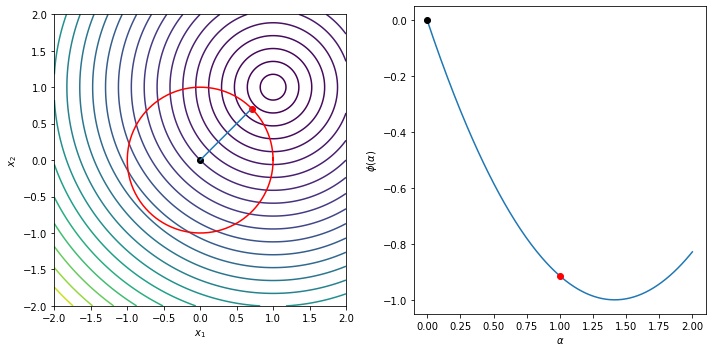

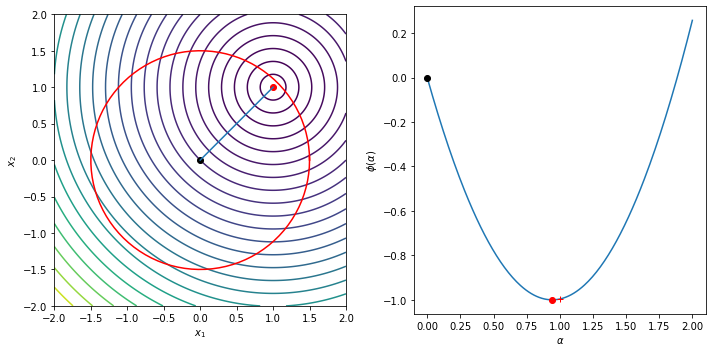

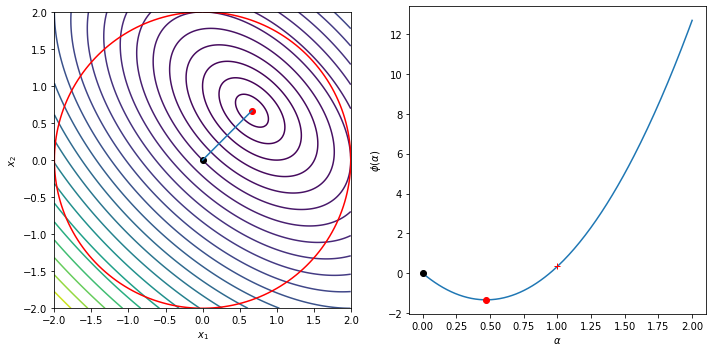

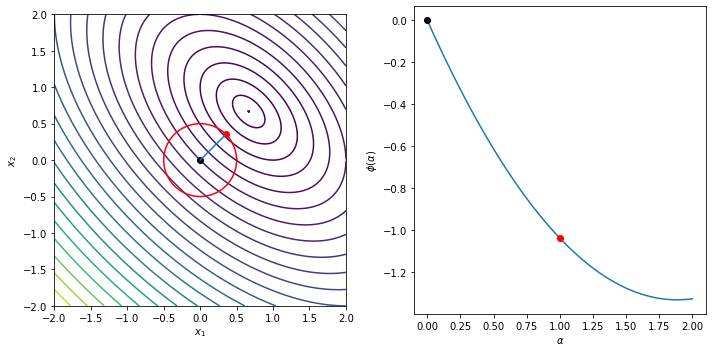

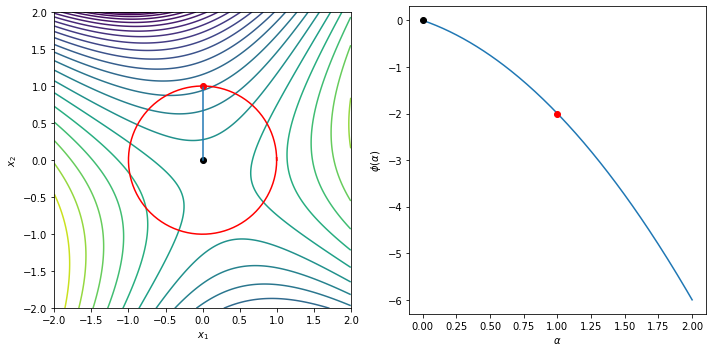

In [20]:
import numpy as np
import matplotlib.pylab as plt

def cauchy_point(g, B, Delta):
    """Given the gradient and the matrix B, find the Cauchy point"""
    
    gnorm = np.sqrt(np.dot(g, g))
    gBg = np.dot(g, np.dot(B, g))
    
    tau = 1.0
    if gBg > 0.0:
        tau = min(1.0, gnorm**3/(Delta*gBg))
    
    return -tau*Delta*g/gnorm

def plot_cauchy(g, B, Delta, xlow=-2, xhigh=2,
                ylow=-2, yhigh=2, n=200):
    """Create a contour plot of the function"""
    
    # Compute the Cauchy step
    sc = cauchy_point(g, B, Delta)
    
    # Plot the contours of the function
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = [X[i, j], Y[i, j]]
            f[i, j] = np.dot(g, x) + 0.5*np.dot(x, np.dot(B, x))

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    levels = np.min(f) + (np.max(f) - np.min(f))*np.linspace(0, 1.0, 25)**2
    ax[0].contour(X, Y, f, levels=levels)
    ax[0].plot(0, 0, color='k', marker='o')
    ax[0].plot(sc[0], sc[1], color='r', marker='o')
    ax[0].plot([0, sc[0]], [0, sc[1]])
    ax[0].set_aspect('equal', 'box')
    
    theta = np.linspace(0, 2*np.pi*(n+2)/(n+1), n)
    ax[0].plot(Delta*np.cos(theta), Delta*np.sin(theta), '-r')

    # Set the boundary of the step
    alpha = np.linspace(0, 2, n)
    
    gnorm = np.sqrt(np.dot(g, g))
    gTg = np.dot(g, g)*(Delta/gnorm)
    gBg = np.dot(g, np.dot(B, g))*(Delta/gnorm)**2
    ax[1].plot(alpha, -alpha*gTg + 0.5*gBg*alpha**2)
               
    # Mark the boundary of the trust region
    alpha = 0.0
    ax[1].plot(alpha, -alpha*gTg + 0.5*gBg*alpha**2, color='k', marker='o')

    tau = 1.0
    if gBg > 0.0:
        tau = min(1.0, gTg/(gBg))

    # Mark the Cauchy step
    alpha = tau
    ax[1].plot(alpha, -alpha*gTg + 0.5*gBg*alpha**2, color='r', marker='o')

    # Mark the trust region boundary step
    alpha = 1.0
    ax[1].plot(alpha, -alpha*gTg + 0.5*gBg*alpha**2, color='r', marker='+')

    ax[0].set_xlabel('$x_1$')
    ax[0].set_ylabel('$x_2$')
    
    ax[1].set_xlabel(r'$\alpha$')
    ax[1].set_ylabel(r'$\phi(\alpha)$')

    fig.tight_layout()    
    
    return

Delta = 1.0
g = np.array([-1, -1])
B = np.array([[1, 0], [0, 1]])
plot_cauchy(g, B, Delta)

Delta = 1.5
g = np.array([-1, -1])
B = np.array([[1, 0], [0, 1]])
plot_cauchy(g, B, Delta)

Delta = 2.0
g = np.array([-2, -2])
B = np.array([[2, 1], [1, 2]])
plot_cauchy(g, B, Delta)

Delta = 0.5
g = np.array([-2, -2])
B = np.array([[2, 1], [1, 2]])
plot_cauchy(g, B, Delta)

Delta = 1.0
g = np.array([0, -1])
B = np.array([[2, 1], [1, -2]])
plot_cauchy(g, B, Delta)
plt.show()

Trust region method failed to converge after 3000 iterations

x =  [0.98845447 0.97702794]
grad(x) =  [-0.01743854 -0.00285927]


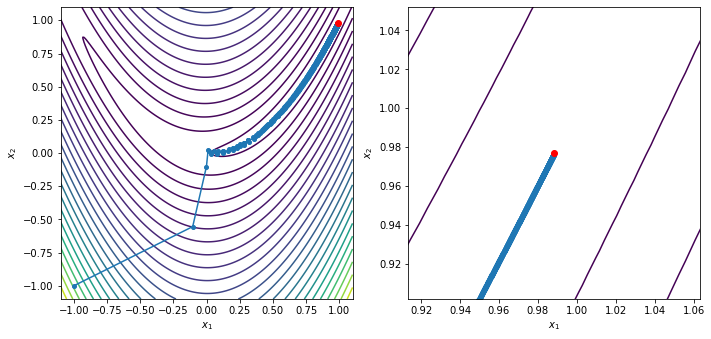

In [21]:
import numpy as np
import matplotlib.pylab as plt

class SR1:
    def __init__(self, n, tol=1e-12):
        self.n = n        
        self.D = np.eye(self.n)
        self.B = np.eye(self.n)
        self.tol = tol
        return
    
    def update(self, s, y):
        """Perform the update"""
        
        # Update the Hessian approximation
        r = y - np.dot(self.B, s)
        beta = np.dot(r, s)
        if np.fabs(beta)/np.dot(s, s) > self.tol:
            self.B += np.outer(r, r)/beta
        
        # Update the approximate inverse Hessian
        r = s - np.dot(self.D, y)
        beta = np.dot(r, y)
        if np.fabs(beta)/np.dot(s, s) > self.tol:
            self.D += np.outer(r, r)/beta
            
        return
    
def trust_region_optimize(x0, func, grad_func, solve_subproblem,
                          eta=0.1, Delta=1.0, Delta_max=100.0,
                          eps=1e-6, max_iters=3000):
    # Make sure we are using a np array
    x = np.array(x0)

    # Store the list of values
    xvals = []
    
    # Allocate the quasi-Newton object that will store
    # the quasi-Newton Hessian approximation
    qn = SR1(len(x))

    # Store the objective and gradient values
    fx = func(x)
    grad = grad_func(x)
    
    for i in range(max_iters):
        xvals.append(np.array(x))

        # Check the norm of the gradient
        if np.sqrt(np.dot(grad, grad)) < eps:
            print('Trust region method found a first-order point in %d iterations\n'%(i))
            return x, np.array(xvals)

        # Solve the subproblem
        s = solve_subproblem(grad, qn.B, Delta)

        # Compute the function at the candidate point
        fs = func(x + s)
        gs = grad_func(x + s)
                
        # Evaluate the model at the step s
        ms = fx + np.dot(grad, s) + 0.5*np.dot(s, np.dot(qn.B, s))
        
        # Compute the ratio of the actual to expected improvement
        rho = (fx - fs)/(fx - ms)
        
        # Perform the quasi-Newton update every time
        y = gs - grad
        qn.update(s, y)

        # Decide whether to accept the step
        if rho > eta:
            fx = fs
            grad[:] = gs[:]
            x[:] = x + s
        
        # Decide whether to update or shrink the trust region
        if rho < 0.25:
            Delta *= 0.25
        elif rho > 0.75:
            Delta = min(2.0*Delta, Delta_max)
        
    print('Trust region method failed to converge after %d iterations\n'%(max_iters))
    return x, np.array(xvals)

def contour_plot_function(func, xvals, xstar,
                          n=250, xlow=-1.1, xhigh=1.1,
                          ylow=-1.1, yhigh=1.1):
    """Create a contour plot of the function"""
    x = np.linspace(xlow, xhigh, n)
    y = np.linspace(ylow, yhigh, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            f[i, j] = func([X[i, j], Y[i, j]])

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    levels = np.min(f) + (np.max(f) - np.min(f))*np.linspace(0, 1.0, 25)**2
    ax[0].contour(X, Y, f, levels=levels)
    ax[0].set_aspect('equal', 'box')

    ax[1].contour(X, Y, f, levels=levels)
    ax[1].set_aspect('equal', 'box')

    ax[0].plot(xvals[:,0], xvals[:,1], marker='o', markersize=4)
    ax[0].plot(xstar[0], xstar[1], 'ro')
    ax[1].plot(xvals[:,0], xvals[:,1], marker='o', markersize=4)
    ax[1].plot(xstar[0], xstar[1], 'ro')

    ax[0].set_xlim(-1.1, 1.1)
    ax[0].set_ylim(-1.1, 1.1)
    ax[0].set_xlabel('$x_1$')
    ax[0].set_ylabel('$x_2$')
    
    ax[1].set_xlim(xstar[0] - 0.075, xstar[0] + 0.075)
    ax[1].set_ylim(xstar[1] - 0.075, xstar[1] + 0.075)
    ax[1].set_xlabel('$x_1$')
    ax[1].set_ylabel('$x_2$')

    fig.tight_layout()    
    
    return

def rosen(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def rosen_grad(x):
    return np.array([-2*(1 - x[0]) - 400*(x[1] - x[0]**2)*x[0], 
                      200*(x[1] - x[0]**2) ])

x0 = [-1.0, -1.0]
xstar, xvals = trust_region_optimize(x0, rosen, rosen_grad, cauchy_point)
contour_plot_function(rosen, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', rosen_grad(xstar))

plt.show()

## Steihaug–Toint algorithm

Unfortunately the Cauchy step doesn't do better than steepest descent.
This is due to the fact that we're just looking in the steepest descent direction within the trust region.
This makes progress, but we can do much better if we look for a better solution to the trust region subproblem.

We want to solve $B s = -g$, but we also need to satisfy $||s||_{2} \le \Delta$.
A simple modification of the conjugate gradient method is:
   
1. If we encounter negative curvature, move to $\Delta$ and exit
2. If we exceed $\Delta$, move to $\Delta$ and exit

Note that for CG method with the initial guess as zero, $||s||_{2}$ increases at every iteration.

For both cases we need to step to the boundary so that we have to solve
\begin{equation*}
||s + \tau p||_{2}^2 = \Delta^2
\end{equation*}

This gives us a quadratic for $\tau$ such that $a \tau^2 + b \tau + c = 0$ where

\begin{equation*}
\begin{aligned}
a &= p^{T}p \\
b &= 2p^{T}s \\
c & = s^{T}s - \Delta^{2} \\
\end{aligned}
\end{equation*}

Since $||s||_{2} \le \Delta$, $c \le 0$ and the positive solution is

\begin{equation*}
\tau = \dfrac{-b + \sqrt{b^2 - 4ac}}{2a}
\end{equation*}

With these definitions, the Steihaug-Toint algorithm is:

1. Set $s = 0$, compute $\gamma = g^{T}g$ and set $p = -g$ and $k = 1$ 
2. Compute $t = Bp$
3. If $t^{T}p < 0$, compute $s \leftarrow s + \tau p$ and exit
4. Compute $\alpha = -\dfrac{p^{T}g}{p^{T}t}$
5. If $||s + \alpha p||_{2} \ge \Delta$, compute $s \leftarrow s + \tau p$ and exit
6. Compute $s \leftarrow s + \alpha p$
7. Compute $g \leftarrow g + \alpha t$
8. Compute $\eta = g^{T}g$
9. If $\sqrt{\eta} < \epsilon$, quit
10. Compute $\beta = \dfrac{\eta}{\gamma}$
11. Set $\gamma \leftarrow \eta$
12. Compute $p = -g + \beta p$
13. Set $k \leftarrow k + 1$ and go to line 2

General comments:

- If there is no negative curvature, and the trust region bound is not violated, Steihaug--Toint reverts to CG
- We do at least as well as the Cauchy point - the first iteration produces the Cauchy point
- If the trust region is violated, we may have a poor estimate of the constrained minimum
- More sophisticated methods exist (e.g. More-Sorensen) that handle the constrained case better


Trust region method found a first-order point in 49 iterations

x =  [1.00000002 1.00000004]
grad(x) =  [ 9.61505744e-08 -2.72625034e-08]


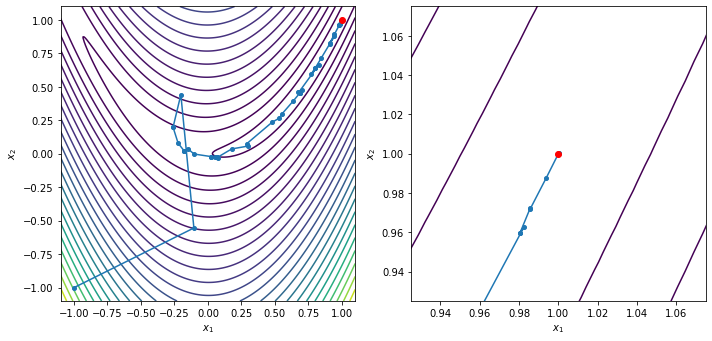

In [22]:
def step_to_boundary(x, p, Delta):
    """
    Given the starting point x and the direction p, compute
    a point such that ||x + tau*p||_{2}^{2} = Delta**2.
    Return the point x + tau*p for tau >= 0.
    """
    c = np.dot(x, x) - Delta**2 # Note that c < 0.0 always
    b = 2.0*np.dot(p, x) # Positive or negative
    a = np.dot(p, p) # Always positive
    
    tau = (-b + np.sqrt(b**2 - 4*a*c))/(2*a)
    return x + tau*p
    
def steihaug_toint(g0, B, Delta, n=100, eps=1e-6):
    """
    The Steihaug--Toint algorithm
    
    This is the conjugate gradient method with two extra steps:
    
    1. We check if we encounter a negative curvature direction.
    2. We check if the solution norm exceeds Delta
    
    In both these cases we take a step all the way to the trust
    region boundary and exit.
    
    This code works with the relationships:
    
    min 0.5*x^{T}*B*x + g^{T}*x such that ||x|| <= Delta
    """
    s = np.zeros(g0.shape)
    
    # Compute the gradient of the function
    g = np.array(g0)
    p = -np.array(g0)
    gamma = np.dot(g, g)
    
    for i in range(n):
        t = np.dot(B, p)
        
        # Check if we have found a negative curvature direction
        pTt = np.dot(p, t)
        if pTt < 0.0:
            return step_to_boundary(s, p, Delta)
        
        alpha = -np.dot(p, g)/pTt
        
        # Check if the candidate step intersects with the
        # trust region boundary.
        st = s + alpha*p
        if np.sqrt(np.dot(st, st)) >= Delta:
            return step_to_boundary(s, p, Delta)

        # Update and continue
        s = s + alpha*p
        g = g + alpha*t
        eta = np.dot(g, g)

        # Check for convergence of the algorithm
        if np.sqrt(eta) < eps:
            break
        
        # Compute the new step
        beta = eta/gamma
        p = -g + beta*p
        gamma = eta
        
    return s
    
x0 = [-1.0, -1.0]
xstar, xvals = trust_region_optimize(x0, rosen, rosen_grad, steihaug_toint)
contour_plot_function(rosen, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', rosen_grad(xstar))

plt.show()
    

## Exact trust region subproblem solution

What if we solve the trust region problem exactly? What will the solution look like?

Consider the case when the quadratic model is positive definite.
In this case, the step may be either within the trust region, or may step all the way to the trust region boundary. Both of these cases are illustrated below.

<img src="trust_region_models.png" width=450>

However, the model may not be positive definite. In this case, the model itself will have no unconstrained minimizer. As a result, the minimizer of the trust region problem will be at the trust region boundary.
This case is illustrated below.

<img src="trust_region_indefinite_model.png" width=400>

We will derive conditions and algorithms that will solve the problem for each of these cases.

In general, the exact solution will satisfy the solution of the following constrained minimization problem

\begin{equation*}
\min_{p} g^{T}p + \frac{1}{2}p^{T}Bp, \qquad \text{such that}\; ||p||_{2} \le \Delta
\end{equation*}

We haven't studied constrained optimization yet.
It turns out we can exactly solve this optimization problem and that it has a global minimizer that can be determined.
The exact solution $p^{*}$ is satisfies the following conditions

\begin{equation*}
\begin{aligned}
(B + \lambda I)p^{*} &= - g \\
(\Delta - ||p^{*}||_{2}) \lambda &= 0 \\
\lambda & \ge 0 \\
(B + \lambda I) & \;\; \text{positive, semi-definite}
\end{aligned}
\end{equation*}

We have to find $p^{*}$ and $\lambda$ that will satisfy these conditions.
Here $\lambda$ is the Lagrange multiplier.
These conditions are called the Karush-Kuhn-Tucker (KKT) conditions. We'll examine these more in greater detail later.

An important aspect of these conditions is called the complementarity constraint:

* Either $||p^{*}||_{2} \le \Delta$ and $\lambda = 0$, or $\lambda \ne 0$ and $||p^{*}||_{2} = \Delta$
  
 




Since $B = B^{T}$ we can use an eigenvalue decomposition: $B = Q\Lambda Q^{T}$, with $QQ^{T} = I$, $\Lambda = \text{diag}\{\lambda_{1}, \lambda_{2},\ldots, \lambda_{n}\}$.
 
 1. We sort $\lambda_{i}$ such that $\lambda_1 \le \lambda_2 \le \ldots \le \lambda_{n}$
 2. For positive, semi-definite $B + \lambda I$, we also have to pick $\lambda$ such that $\lambda \ge - \lambda_{1}$ since $\text{eigs}(B + \lambda I) = \Lambda + \lambda$
 3. The Lagrange multiplier must be greater than the negative of the minimum eigenvalue of $B$
 
 * If $(B + \lambda I)$ is non-singular, $p^{*}(\lambda) = -(B + \lambda I)^{-1}g$, we can compute $p^{*}(\lambda)$ as follows:
 
\begin{equation*}
\begin{aligned}
p^{*}(\lambda) 
& = -(Q\Lambda Q^{T} + \lambda I)^{-1}g \\
& = -(Q(\Lambda + \lambda I)Q^{T})^{-1}g  \\
& = -Q(\Lambda + \lambda I)^{-1}Q^{T}g
\end{aligned}
\end{equation*}
  
Now we just have to find $\lambda$ such that $\lambda \ge - \lambda_{1}$, $\lambda \ge 0$, and $||p^{*}(\lambda)||_{2} \le \Delta$.

### Properties of $p^{*}$

How do we enforce $||p^{*}(\lambda)||_{2} \le \Delta$? Using our expression for $p^{*}(\lambda)$, we get the following expression for the magnitude of $p^{*}(\lambda)$:
  
\begin{equation*}
\begin{aligned}
||p^{*}(\lambda)||_{2}^{2} & = ||Q(\Lambda + \lambda I)^{-1}Q^{T}g||_{2}^{2} \\
& = (Q(\Lambda + \lambda I)^{-1}Q^{T}g)^{T}Q(\Lambda + \lambda I)^{-1}Q^{T}g \\
& = g^{T}Q(\Lambda + \lambda I)^{-2}Q^{T}g \\
& = \sum_{i=1}^{n} \frac{(q_{i}^{T}g)^2}{(\lambda_{i} + \lambda)^2} \le \Delta^2
\end{aligned}
\end{equation*}

Poles of $||p^{*}(\lambda)||_{2}^2$ correspond to $\lambda = -\lambda_{i}$

1. If $B$ is positive definite, poles are all located in $\lambda < 0$, but we require $\lambda \ge 0$ so this won't cause any issues
2. If $B$ is indefinite, we have both positive/negative poles, and we require $\lambda \ge -\lambda_{1}$ (where $\lambda_1 < 0$) so that $B + \lambda I$ is positive semi-definite
3. If $g^{T}q_{i} = 0$, or $g^{T}q_{i} \ll 1$, we need to be extra careful because the expression for $||p^{*}(\lambda)||_{2}^{2}$ won't capture the critical pole $\lambda = - \lambda_1$ - this is the *hard case*

### Example 1

Find the exact minimizer for the trust region subproblem with $\Delta = 1/2$ and

\begin{equation*}
g = \begin{bmatrix} -1 \\ -1 \end{bmatrix} \qquad B = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
\end{equation*}

Note: $B$ is positive definite. The model $m(p)$ has a minimizer and is located at 

\begin{equation*}
p_{\min} = - B^{-1} g = \begin{bmatrix} 1 \\ 1 \end{bmatrix}
\end{equation*}

Check whether this step violates the trust region bound: $||p_{\min}||_{2} = \sqrt{2} > \Delta$. We can't take a full step to the minimizer. So we know that we have to have $||p^{*}(\lambda)||_{2} = \Delta$.

\begin{equation*}
||p^{*}(\lambda)||_{2}^2 = \frac{(-1)^2}{(1 + \lambda)^2} + \frac{(-1)^2}{(1 + \lambda)^2} = \frac{1}{4}
\end{equation*}

Rearrange and solve for the roots:

\begin{equation*}
(1 + \lambda)^2 = 8 \qquad \implies \qquad \lambda = -1  \pm 2 \sqrt{2}
\end{equation*}

Pick $\lambda = -1 + 2 \sqrt{2} \ge 0$ since this is required. Note that this choice will always be unique.
Now we can solve $(B + \lambda I) p = - g$.

\begin{equation*}
B + \lambda I = \begin{bmatrix} 1 + \lambda & 0 \\ 0 & 1 + \lambda \end{bmatrix} = \begin{bmatrix} 2 \sqrt{2} & 0 \\ 0 & 2 \sqrt{2} \end{bmatrix}
\end{equation*}
	
\begin{equation*}
\begin{bmatrix} 2 \sqrt{2} & 0 \\ 0 & 2 \sqrt{2} \end{bmatrix} p = -g \qquad \implies \qquad p^{*} = \frac{1}{2\sqrt{2}} \begin{bmatrix} 1 \\ 1 \end{bmatrix}
\end{equation*}
	
Check that $||p^{*}|| = \Delta$.

### Example 2

Find the minimizer of the following trust region subproblem as a function of $\Delta$

\begin{equation*}
B = \begin{bmatrix} 1 & 0 \\ 0 & 2 \end{bmatrix} \qquad\qquad g = \begin{bmatrix} -1 \\  -1 \end{bmatrix}
\end{equation*}

$B$ is positive definite, so the model minimizer is

\begin{equation*}
p_{\min} = -B^{-1} g = \begin{bmatrix} 1 & \frac{1}{2} \end{bmatrix}
\end{equation*}

Solution becomes constrained when $\Delta \le \sqrt{ p_{\min}^{T} p_{\min}} = \sqrt{5}/2$.

\begin{equation*}
||p^{*}(\lambda)||_{2}^{2} = \frac{(-1)^2}{(1 + \lambda)^2} + \frac{(-1)^2}{(2 + \lambda)^2} = \Delta^2 
\end{equation*}

Rearrange and solve for the roots of the equation:

\begin{equation*}
(2 + \lambda)^2 + (1 + \lambda)^2 = \Delta^2 (1 + \lambda)^2 (2 + \lambda)^2
\end{equation*}

\begin{equation*}
\lambda = \frac{1}{2} \left\{ \sqrt{\frac{4 + \Delta^2 - 4 \sqrt{\Delta^2 + 1}}{\Delta^2}} - 3\right\}
\end{equation*}

### Example 3

Find the minimizer of the following trust region subproblem for $\Delta = 1$

\begin{equation*}
B = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} \qquad\qquad g = \begin{bmatrix} -1 \\  -1 \end{bmatrix}
\end{equation*}
    
This model is indefinite so there will be no model minimizer. Instead, we have to solve directly for the constrained optimization solution.

\begin{equation*}
||p(\lambda)||_{2}^2 = \frac{1}{(\lambda + 1)^2} + \frac{1}{(\lambda - 1)^2} = \Delta^2 = 1
\end{equation*}
    
Find the quartic equation for $\lambda$:

\begin{equation*}
(\lambda - 1)^2 + (\lambda + 1)^2 = (\lambda + 1)^2(\lambda - 1)^2 \;\; \implies \;\; \lambda^4 - 4\lambda^2 - 1 = 0 
\end{equation*}
    
The solution is $\lambda^2 = 2 \pm \sqrt{5}$ so $\lambda \pm \sqrt{2 + \sqrt{5}}$ are real roots. Only the solution $\lambda = \sqrt{2 + \sqrt{5}} \ge -\lambda_{1} = 1$.

Another way to look at this problem is to plot the model function in terms of the position around the trust region radius:

\begin{equation*}
p = \Delta \begin{bmatrix} \cos(\theta) \\ \sin(\theta) \end{bmatrix}
\end{equation*}
    
\begin{equation*}
m(p(\theta)) = \frac{1}{2} p^{T} B p + p^{T} g = \frac{1}{2} \Delta^2 cos(2\theta) - \Delta (\cos(\theta) + \sin(\theta))
\end{equation*}

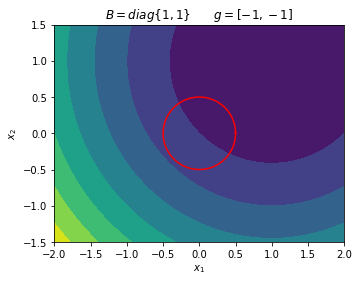

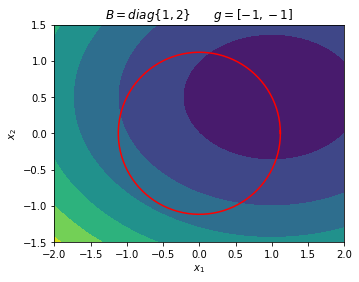

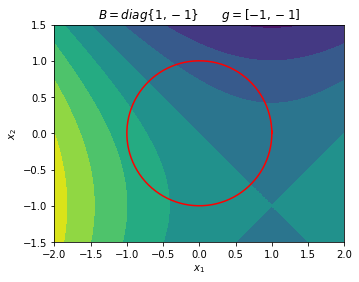

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_quadratic_contour(B, g, xdim=2):
    # Generate plot
    n = 100
    x = np.linspace(-xdim, xdim, n)
    y = np.linspace(-0.75*xdim, 0.75*xdim, n)
    X, Y = np.meshgrid(x, y)
    f = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            x = np.array([X[i,j], Y[i,j]])
            f[i, j] = 0.5*np.dot(x, np.dot(B, x)) + np.dot(x, g)

    fig, ax = plt.subplots(1, 1)
    ax.contourf(X, Y, f)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    ax.set_aspect('equal', 'box')

    return

n = 200
theta = np.linspace(0, 2*np.pi*(n+1)/n, n)

# Example 1
B = np.array([[1.0, 0.0], [0.0, 1.0]])
g = np.array([-1.0, -1.0])
plot_quadratic_contour(B, g)
plt.title('$B = diag\{1, 1\} \qquad g = [-1, -1]$')

x = 0.5*np.cos(theta)
y = 0.5*np.sin(theta)
plt.plot(x, y, 'r')

# Example 2
B = np.array([[1.0, 0.0], [0.0, 2.0]])
g = np.array([-1.0, -1.0])
plot_quadratic_contour(B, g)
plt.title('$B = diag\{1, 2\} \qquad g = [-1, -1]$')

x = np.sqrt(5)/2*np.cos(theta)
y = np.sqrt(5)/2*np.sin(theta)
plt.plot(x, y, 'r')

# Example 3
B = np.array([[1.0, 0.0], [0.0, -1.0]])
g = np.array([-1.0, -1.0])
plot_quadratic_contour(B, g)
plt.title('$B = diag\{1, -1\} \qquad g = [-1, -1]$')

x = np.cos(theta)
y = np.sin(theta)
plt.plot(x, y, 'r')

plt.show()

## Example: Exact step computation for 2D problems



Trust region method found a first-order point in 67 iterations

x =  [1. 1.]
grad(x) =  [ 4.78431938e-09 -2.58926214e-09]


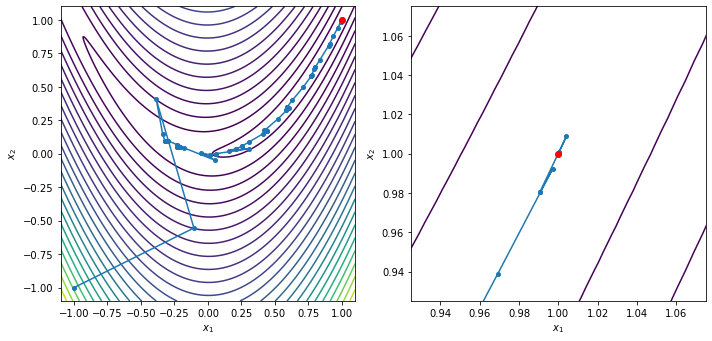

In [27]:
import numpy as np

def compute_lambda(c, eig, Delta, max_iters=10, tol=1e-6, eps=1e-12):
    """
    Solve the trust region norm using the secular equation.
    
    This method is a simplifed version of the method presented in Conn, Gould and Toint
    (Section 7.3.3). This method is not described in the course notes here.
    """
    # Instead of using Newton's method applied to the equation:
    # ||p^{*}(lam)||^2  - Delta^2 = np.dot(c/(lam + eig)**2) -Delta^2 = 0
    # Solve the secular equation:
    # 1/||p^{*}(lam)|| - 1/Delta = 0
    
    # If the first coefficient is small, just use lam = -eig[0] + 1e-6
    if c[0] < tol:
        if eig[0] < 0.0:
            return -eig[0] + tol
        else:
            return tol
            
    # Pick a starting point close to the smallest allowable value
    if eig[0] < tol:
        lam = -eig[0] + tol
    else:
        lam = eig[0]

    for i in range(max_iters):
        # Compute 1.0/||p(lam)||_{2} - 1.0/Delta = 0
        pnorm = np.sqrt(np.sum(c/(eig + lam)**2))
        r = 1.0/pnorm - 1.0/Delta
        
        # If the residual is satisfied, exit
        if np.fabs(r) < eps:
            break
        
        # Compute the derivative of pnorm w.r.t. lambda
        dpnorm = -(1/pnorm)*np.sum(c/(eig + lam)**3)
        
        # Compute the derivative of r w.r.t. pnorm
        dr = -dpnorm/pnorm**2
        
        # Update the lambda guess
        lam -= r/dr
        
    return lam
    
def exact_trust_region(g, B, Delta):
    """
    Compute the exact trust region step.
    
    Note that this function utilizes a full eigenvalue decomposition.
    
    Args:
    g:     The gradient of the model function
    B      The quasi-Newton Hessian approximation
    Delta: The trust region radius
    """
    # Compute the full eigenvalue decomposition for B = Q*Lambda*Q^{T}
    eig, Q = np.linalg.eigh(B)
    
    # Check the smallest eigenvalue. If it's positive, compute the
    # full step s = - B^{-1}*g. Note that B^{-1} = Q*Lambda^{-1}*Q^{T}
    if eig[0] > 0.0:
        s = -np.dot(Q, 1.0/eig*np.dot(Q.T, g))
        
        # The unconstrained minimizer 
        if np.sqrt(np.dot(s, s)) <= Delta:
            return s
        
    # Compute the coefficients c[i] = (Q[:,i]^{T}*g)^2
    c = np.dot(Q.T, g)**2
    
    # Compute lambda
    lam = compute_lambda(c, eig, Delta)
    
    if lam < 0.0 or lam < -eig[0]:
        print('Violation of exact trust-region condition on lambda')

    # Compute the shifted eigenvalues
    eig_shifted = eig + lam
    inv_shifted = 1.0/eig_shifted
    
    pstar = -np.dot(Q, inv_shifted*np.dot(Q.T, g))
    
    if np.fabs(np.sqrt(np.dot(pstar, pstar)) - Delta) > 1e-12:
        print('Trust region solution does not satisfy conditions')
    
    return pstar

x0 = [-1.0, -1.0]
xstar, xvals = trust_region_optimize(x0, rosen, rosen_grad, exact_trust_region)
contour_plot_function(rosen, xvals, xstar)
print('x = ', xstar)
print('grad(x) = ', rosen_grad(xstar))